Failed encoding utf-8: UnicodeDecodeError - 'utf-8' codec can't decode byte 0xa3 in position 16: invalid start byte
Failed encoding utf-8-sig: UnicodeDecodeError - 'utf-8' codec can't decode byte 0xa3 in position 7092: invalid start byte
Loaded '/content/Stock News Dataset.csv' with encoding=cp1252 shape=(4101, 27)
After preprocess, shape: (4101, 31)
Label distribution:
 Label
1    2166
0    1935
Name: count, dtype: int64
IQR bounds: -292.5 .. 879.5
Outlier count: 0
Time-aware split used: train=3280 test=821
Training pipeline ...
[LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Info] Number of positive: 1728, number of negative: 1552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.226375 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 134135
[LightGBM] [Info] Number of data points in the train set: 3280, number of used features: 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: is_unbalanced

Classification report (test):
              precision    recall  f1-score   support

 Decrease(0)     0.4927    0.3525    0.4110       383
 Increase(1)     0.5466    0.6826    0.6071       438

    accuracy                         0.5286       821
   macro avg     0.5197    0.5176    0.5090       821
weighted avg     0.5215    0.5286    0.5156       821

Confusion matrix:
 [[135 248]
 [139 299]]


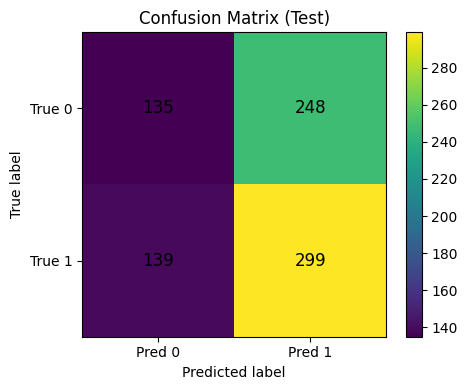


Top TF-IDF features by LightGBM importance:
 1. say (imp=162)
 2. world (imp=144)
 3. new (imp=138)
 4. talk (imp=129)
 5. national (imp=125)
 6. day (imp=123)
 7. iran (imp=122)
 8. extra (imp=122)
 9. man (imp=122)
10. tv (imp=113)
11. job (imp=111)
12. year (imp=108)
13. card (imp=107)
14. great (imp=105)
15. make (imp=102)
16. blair (imp=99)
17. time (imp=98)
18. letter (imp=98)
19. voter (imp=97)
20. warning (imp=94)
21. cool (imp=94)
22. plan (imp=88)
23. scene (imp=87)
24. city (imp=86)
25. sun (imp=86)

Saved pipeline to artifacts/lgbm_headlines_pipeline.joblib


In [ ]:
# ======= Colab-ready: install dependencies =======
!pip -q install lightgbm scikit-learn pandas matplotlib nltk joblib

# ======= Imports =======
import os, re, string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)   # sometimes required for lemmatizer

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from lightgbm import LGBMClassifier
import joblib

# ======= 0) Robust CSV load (single read) =======
CSV_PATH = "/content/Stock News Dataset.csv"   # change if needed

# List of strings to treat as NaN
missing_values = ["?", "N/A", "na", "null", " ", ""]

# Try a list of encodings until one works
def load_csv(path):
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin1"):
        try:
            df = pd.read_csv(path, encoding=enc, na_values=missing_values)
            print(f"Loaded '{path}' with encoding={enc} shape={df.shape}")
            return df
        except Exception as e:
            print(f"Failed encoding {enc}: {type(e).__name__} - {str(e)[:120]}")
    raise RuntimeError("Could not read CSV with tried encodings.")

df = load_csv(CSV_PATH)

# ======= 1) Check expected columns and prepare headlines =======
# Expect Top1..Top25 present in dataset
headline_cols = [f"Top{i}" for i in range(1, 26)]
present_headline_cols = [c for c in headline_cols if c in df.columns]

if len(present_headline_cols) == 0:
    raise ValueError("Dataset is missing Top1..Top25 headline columns. Found columns: " + ", ".join(df.columns))

# Keep only rows where Label exists (do not drop valid headline rows unnecessarily)
df = df.copy()
df['Label'] = df['Label'].astype('float')   # temporarily allow NaN
df = df.dropna(subset=['Label'])            # drop rows missing label
df['Label'] = df['Label'].astype(int)

# Fill missing headlines with empty strings then combine
df[present_headline_cols] = df[present_headline_cols].fillna("")
df['Combined_News'] = df[present_headline_cols].astype(str).agg(' '.join, axis=1)

# Parse Date safely
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# ======= 2) Text cleaning / preprocessing =======
# cleaner function (keeps only letters, collapses spaces)
def clean_text(text):
    text = str(text).lower()
    # remove punctuation and digits; keep letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Cleaned_News'] = df['Combined_News'].apply(clean_text)

# NLTK stopwords & lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_tokens(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df['Processed_News'] = df['Cleaned_News'].apply(preprocess_tokens)

# headline length (word count) for EDA
df['headline_length'] = df['Combined_News'].astype(str).str.split().apply(len)

print("After preprocess, shape:", df.shape)
print("Label distribution:\n", df['Label'].value_counts())

# ======= 3) Outlier detection (IQR) & EDA visuals =======
Q1 = df['headline_length'].quantile(0.25)
Q3 = df['headline_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"IQR bounds: {lower_bound:.1f} .. {upper_bound:.1f}")
outliers = df[(df['headline_length'] < lower_bound) | (df['headline_length'] > upper_bound)]
print("Outlier count:", len(outliers))


# ======= 4) Train / Test split (time-aware) =======
# Sort by Date when possible. If Date is mostly NaT, fallback to random split.
if df['Date'].notna().sum() / len(df) > 0.1:
    df_sorted = df.sort_values('Date').reset_index(drop=True)
    split_idx = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:split_idx].copy()
    test_df  = df_sorted.iloc[split_idx:].copy()
    print(f"Time-aware split used: train={len(train_df)} test={len(test_df)}")
else:
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Label'])
    print(f"Random stratified split used: train={len(train_df)} test={len(test_df)}")

X_train = train_df['Processed_News'].values
y_train = train_df['Label'].values
X_test  = test_df['Processed_News'].values
y_test  = test_df['Label'].values

# ======= 5) Model pipeline (TF-IDF -> LightGBM) =======
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words='english', min_df=2)
lgbm = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    is_unbalanced=True,
    n_jobs=-1
)

pipeline = Pipeline([
    ('tfidf', tfidf),
    ('clf', lgbm)
])

print("Training pipeline ...")
pipeline.fit(X_train, y_train)
print("Training complete.")

# ======= 6) Evaluation: classification report & confusion matrix =======
y_pred = pipeline.predict(X_test)
print("\nClassification report (test):")
print(classification_report(y_test, y_pred, digits=4, target_names=["Decrease(0)", "Increase(1)"]))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (Test)")
plt.colorbar()
plt.xticks([0,1], ['Pred 0', 'Pred 1'])
plt.yticks([0,1], ['True 0', 'True 1'])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center', fontsize=12)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

# ======= 7) Optional: top feature importances =======
# We can map LGBM feature_importances_ back to TF-IDF feature names
tfidf_feat_names = pipeline.named_steps['tfidf'].get_feature_names_out()
model = pipeline.named_steps['clf']
if hasattr(model, "feature_importances_"):
    fi = model.feature_importances_
    top_n = 25
    idxs = np.argsort(fi)[::-1][:top_n]
    print("\nTop TF-IDF features by LightGBM importance:")
    for rank, idx in enumerate(idxs, start=1):
        print(f"{rank:2d}. {tfidf_feat_names[idx]} (imp={fi[idx]})")

# ======= 8) Save pipeline =======
os.makedirs("artifacts", exist_ok=True)
joblib.dump(pipeline, "artifacts/lgbm_headlines_pipeline.joblib")
print("\nSaved pipeline to artifacts/lgbm_headlines_pipeline.joblib")
